# Wpływ zmiany dropoutu na model CNN na zbiorze CIFAR-10

Celem eksperymentu jest proste porównanie dwóch wariantów tego samego modelu:

- dropout wyłączony
- dropout włączony

Nie wykorzystujemy zewnętrznych obrazów. Wynik jest oceniany na zbiorze testowym CIFAR-10.

In [1]:
import adom_library as adom
import pandas as pd
import matplotlib.pyplot as plt

adom.show_device()

cuda


## Parametry eksperymentu

Wartość `dropout_value = None` oznacza w tej bibliotece wyłączenie dropout, ponieważ funkcja `set_dropout` zamienia warstwy dropout na `Identity`.


In [2]:
MODEL_TYPE = "VGG16"
EPOCHS = 10
BATCH_SIZE = 64

DROPOUT_OFF = None
DROPOUT_ON = 0.5

## Wczytanie CIFAR-10

Używamy zbioru treningowego do uczenia oraz zbioru testowego do końcowej oceny.

In [3]:
train_dataset = adom.get_CIFAR10_dataset(train_dataset=True)
test_dataset = adom.get_CIFAR10_dataset(train_dataset=False)

classes = train_dataset.classes

print("Liczba klas:", len(classes))
print("Klasy:", classes)
print("Liczba obrazów treningowych:", len(train_dataset))
print("Liczba obrazów testowych:", len(test_dataset))

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000


## Trening modelu bez dropout

In [4]:
model_without_dropout = adom.train_new_model(
    train_dataset=train_dataset,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    dropout_value=DROPOUT_OFF,
)

adom.save_model(model=model_without_dropout, model_name="dropout-model_without_dropout", classes=classes)

Training VGG for 10 epochs...
Epoch 1, Loss: 1.4603, Acc: 47.05%, Time: 249.83s
Epoch 2, Loss: 0.8587, Acc: 70.00%, Time: 249.48s
Epoch 3, Loss: 0.5322, Acc: 81.67%, Time: 249.43s
Epoch 4, Loss: 0.2629, Acc: 90.95%, Time: 249.67s
Epoch 5, Loss: 0.1058, Acc: 96.51%, Time: 249.91s
Epoch 6, Loss: 0.0708, Acc: 97.77%, Time: 249.80s
Epoch 7, Loss: 0.0526, Acc: 98.33%, Time: 250.00s
Epoch 8, Loss: 0.0471, Acc: 98.46%, Time: 249.90s
Epoch 9, Loss: 0.0412, Acc: 98.74%, Time: 249.40s
Epoch 10, Loss: 0.0387, Acc: 98.74%, Time: 250.04s
Total training time: 2497.47s


## Trening modelu z dropout

In [5]:
model_with_dropout = adom.train_new_model(
    train_dataset=train_dataset,
    model_type=MODEL_TYPE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    dropout_value=DROPOUT_ON,
)

adom.save_model(model=model_with_dropout, model_name="dropout-model_with_dropout_" + str(DROPOUT_ON), classes=classes)

Training VGG for 10 epochs...
Epoch 1, Loss: 1.5768, Acc: 42.17%, Time: 248.40s
Epoch 2, Loss: 0.9566, Acc: 66.39%, Time: 246.34s
Epoch 3, Loss: 0.6667, Acc: 76.99%, Time: 245.41s
Epoch 4, Loss: 0.4388, Acc: 84.96%, Time: 246.65s
Epoch 5, Loss: 0.2448, Acc: 91.72%, Time: 248.47s
Epoch 6, Loss: 0.1414, Acc: 95.23%, Time: 249.19s
Epoch 7, Loss: 0.0937, Acc: 96.83%, Time: 248.82s
Epoch 8, Loss: 0.0763, Acc: 97.52%, Time: 245.94s
Epoch 9, Loss: 0.0654, Acc: 97.79%, Time: 248.77s
Epoch 10, Loss: 0.0543, Acc: 98.15%, Time: 247.44s
Total training time: 2475.44s


## Ewaluacja modeli na CIFAR-10

Najważniejsza metryka do porównania wpływu dropout to **test accuracy**, ponieważ pokazuje skuteczność modelu na danych niewidzianych podczas treningu.

In [6]:
train_result_without_dropout = adom.evaluate_model_on_dataset(
    model_without_dropout,
    train_dataset,
    classes,
    batch_size=64,
)

test_result_without_dropout = adom.evaluate_model_on_dataset(
    model_without_dropout,
    test_dataset,
    classes,
    batch_size=64,
)

train_result_with_dropout = adom.evaluate_model_on_dataset(
    model_with_dropout,
    train_dataset,
    classes,
    batch_size=64,
)

test_result_with_dropout = adom.evaluate_model_on_dataset(
    model_with_dropout,
    test_dataset,
    classes,
    batch_size=64,
)

## Wyniki

In [7]:
results = [
    {
        "wariant": "dropout wyłączony",
        "dropout_value": "None",
        "train_accuracy_percent": train_result_without_dropout["accuracy_percent"],
        "test_accuracy_percent": test_result_without_dropout["accuracy_percent"],
        "train_loss": train_result_without_dropout["avg_loss"],
        "test_loss": test_result_without_dropout["avg_loss"],
        "parameters": adom.count_model_params(model_without_dropout),
    },
    {
        "wariant": "dropout włączony",
        "dropout_value": DROPOUT_ON,
        "train_accuracy_percent": train_result_with_dropout["accuracy_percent"],
        "test_accuracy_percent": test_result_with_dropout["accuracy_percent"],
        "train_loss": train_result_with_dropout["avg_loss"],
        "test_loss": test_result_with_dropout["avg_loss"],
        "parameters": adom.count_model_params(model_with_dropout),
    },
]

results_df = pd.DataFrame(results)
results_df

,wariant,dropout_value,train_accuracy_percent,test_accuracy_percent,train_loss,test_loss,parameters
0,dropout wyłączony,None,99.018,76.63,0.031148,1.057513,134301514
1,dropout włączony,0.5,99.694,79.24,0.009760,1.036078,134301514


## Wykres porównawczy

Powinniśmy zaobserwować, że dokładność na zbiorze treningowym spadła po zastosowaniu dropout, co jest spodziewane, ponieważ model jest mniej dopasowany do danych treningowych. Jednak dokładność na zbiorze testowym może być wyższa z powodu lepszej generalizacji, co jest głównym celem stosowania dropoutu.

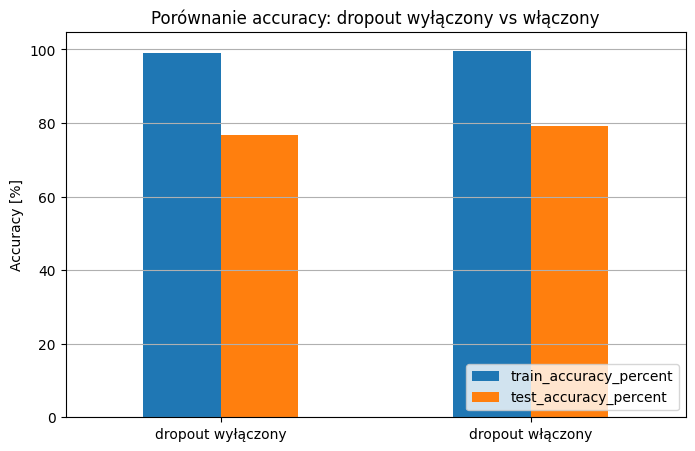

In [8]:
plot_df = results_df.set_index("wariant")[[
    "train_accuracy_percent",
    "test_accuracy_percent",
]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_title("Porównanie accuracy: dropout wyłączony vs włączony")
ax.set_ylabel("Accuracy [%]")
ax.set_xlabel("")
ax.grid(axis="y")
ax.legend(loc="lower right")

plt.xticks(rotation=0)
plt.show()

## Różnica między wynikiem treningowym i testowym

Ta różnica pomaga zauważyć, czy model mocno dopasowuje się do zbioru treningowego. Większa różnica między `train_accuracy` i `test_accuracy` może sugerować większe przeuczenie modelu.

In [9]:
results_df["accuracy_gap_train_minus_test"] = (
    results_df["train_accuracy_percent"] - results_df["test_accuracy_percent"]
)

results_df[[
    "wariant",
    "dropout_value",
    "train_accuracy_percent",
    "test_accuracy_percent",
    "accuracy_gap_train_minus_test",
]]

,wariant,dropout_value,train_accuracy_percent,test_accuracy_percent,accuracy_gap_train_minus_test
0,dropout wyłączony,None,99.018,76.63,22.388
1,dropout włączony,0.5,99.694,79.24,20.454


## Podsumowanie

W eksperymencie porównano dwa warianty tego samego modelu CNN uczonego na zbiorze CIFAR-10. Pierwszy wariant miał dropout wyłączony, natomiast drugi wariant wykorzystywał dropout o zadanej wartości. Oba modele trenowano przez taką samą liczbę epok, z tym samym optymalizatorem oraz na tym samym zbiorze danych.

Celem eksperymentu było sprawdzenie, czy zastosowanie dropout poprawia generalizację modelu (czyli wynik osiągany na danych testowych). Porównano dokładność na zbiorze treningowym oraz testowym. Szczególną uwagę zwrócono na różnicę między dokładnością treningową i testową, ponieważ może ona wskazywać na stopień przeuczenia modelu.

Jeżeli model z dropout osiąga niższy wynik treningowy, ale podobny lub lepszy wynik testowy, może to oznaczać, że dropout ogranicza przeuczenie.

## Wnioski

Po włączeniu dropout, można zaobserwować poprawę dokładności na zbiorze testowym z 76,63% do 79,24%, czyli o około 2,61 punktu procentowego, co sugeruje lepszą generalizację modelu.

Warto zauważyć, że zastosowanie dropout nie zmieniło liczby parametrów modelu (jest ta sama liczba parametrów). Oznacza to, że poprawa wyniku testowego nie wynikała ze zwiększenia pojemności sieci, lecz z działania mechanizmu regularizacji.

Dokładność na zbiorze treningowym w przypadku stosowania dropout może być niższa, jednak w przeprowadzonym eksperymencie osiągnięto wartość praktycznie identyczną (różnica mniejsza od 1%). Różnica między dokładnością treningową i testową nadal pozostaje duża, co wskazuje, że model wciąż wykazuje oznaki przeuczenia. Dropout zmniejszył jednak tę różnicę z około 22,39 p.p. do około 20,45 p.p., a jednocześnie poprawił dokładność testową z 76,63% do 79,24%. Można więc uznać, że w tym eksperymencie dropout poprawił generalizację modelu, jednak nie wyeliminował całkowicie problemu przeuczenia.